## DATA 1030 Final Project

## Name: Vaishu Chintam

## Link to your github repo: https://github.com/vaishuc17/data1030finalproject.git

## Load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import pylab as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# read in the dataset
df = pd.read_csv('../data/diabetes_012_health_indicators_BRFSS2015.csv')
print(f"There are {df.shape[0]} rows of data and {df.shape[1]} columns in the dataset\n")
# turn all values into integers since they are all whole numbers and floats take up extra memory
df = df.astype('int64')
print(df.head())
# prepare the feature matrix X
X = df.loc[:, df.columns != 'Diabetes_012']
# prepare the target variable y
y = df['Diabetes_012']

There are 253680 rows of data and 22 columns in the dataset

   Diabetes_012  HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  \
0             0       1         1          1   40       1       0   
1             0       0         0          0   25       1       0   
2             0       1         1          1   28       0       0   
3             0       1         0          1   27       0       0   
4             0       1         1          1   24       0       0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                     0             0       0  ...              1   
1                     0             1       0  ...              0   
2                     0             0       1  ...              1   
3                     0             1       1  ...              1   
4                     0             1       1  ...              1   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex  Age  Education  \
0            0        5        

## Exploratory Data Analysis

### Summary Statistics

In [2]:
# display columns and dtypes
df.info()

# calculate num of missing values per col 
print(f"\nNumber of missing values per column:\n{df.isna().sum()}\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Diabetes_012          253680 non-null  int64
 1   HighBP                253680 non-null  int64
 2   HighChol              253680 non-null  int64
 3   CholCheck             253680 non-null  int64
 4   BMI                   253680 non-null  int64
 5   Smoker                253680 non-null  int64
 6   Stroke                253680 non-null  int64
 7   HeartDiseaseorAttack  253680 non-null  int64
 8   PhysActivity          253680 non-null  int64
 9   Fruits                253680 non-null  int64
 10  Veggies               253680 non-null  int64
 11  HvyAlcoholConsump     253680 non-null  int64
 12  AnyHealthcare         253680 non-null  int64
 13  NoDocbcCost           253680 non-null  int64
 14  GenHlth               253680 non-null  int64
 15  MentHlth              253680 non-n

In [19]:
# call describe() and value_counts() on all features to get a better understanding of them
for col in df.columns:
    print(df[col].describe(), "\n")
    print(df[col].value_counts(), "\n")

count    253680.000000
mean          0.296921
std           0.698160
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           2.000000
Name: Diabetes_012, dtype: float64 

Diabetes_012
0    213703
2     35346
1      4631
Name: count, dtype: int64 

count    253680.000000
mean          0.429001
std           0.494934
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: HighBP, dtype: float64 

HighBP
0    144851
1    108829
Name: count, dtype: int64 

count    253680.000000
mean          0.424121
std           0.494210
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: HighChol, dtype: float64 

HighChol
0    146089
1    107591
Name: count, dtype: int64 

count    253680.000000
mean          0.962670
std           0.189571
min           0.000000
25%           1.000000
50%           1.000000
75%         

### Visualizations

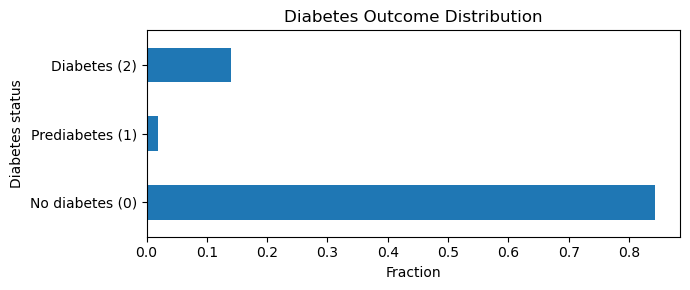

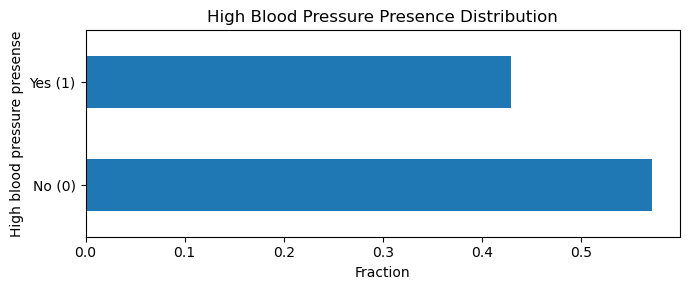

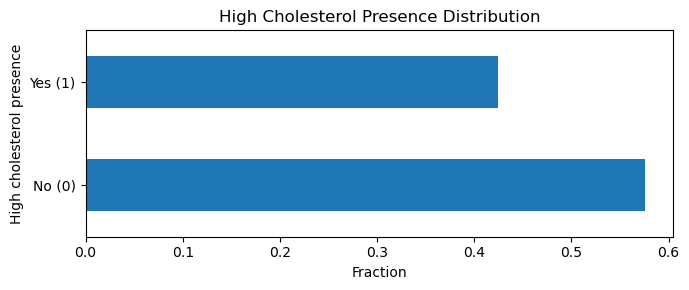

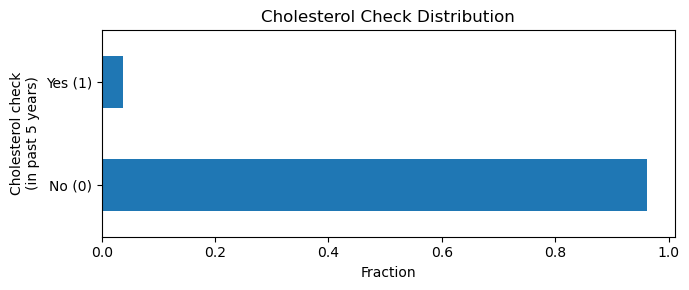

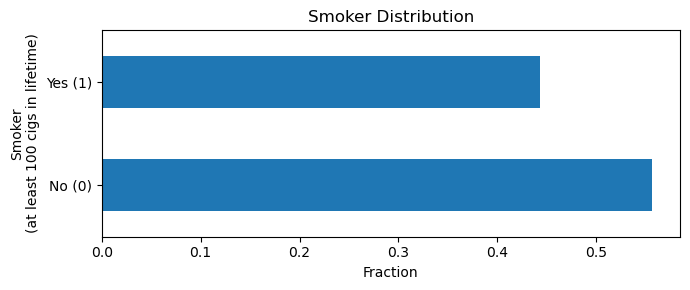

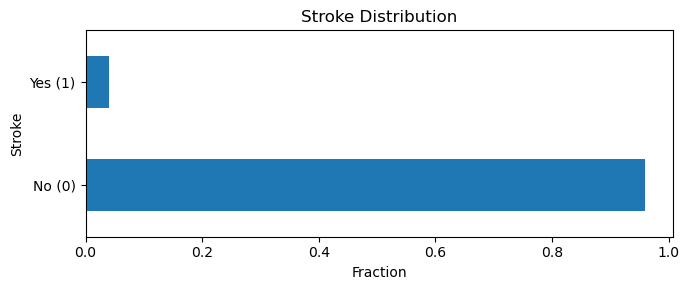

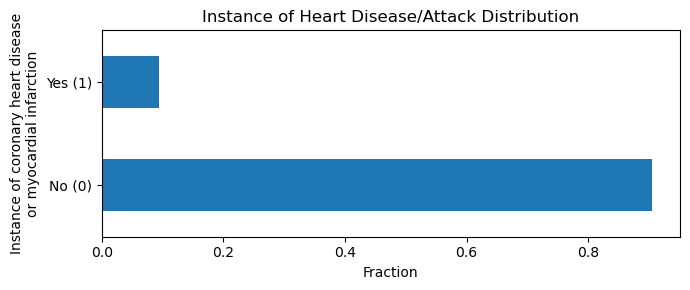

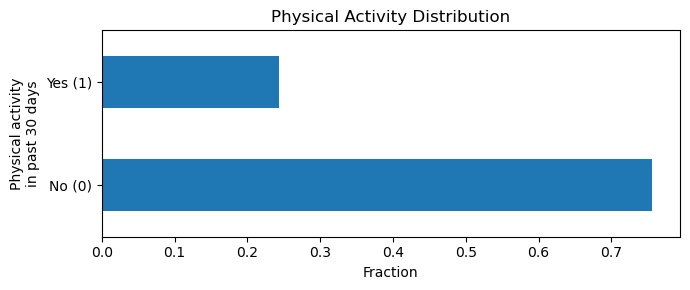

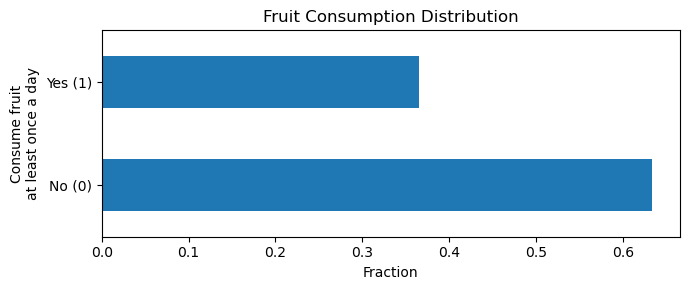

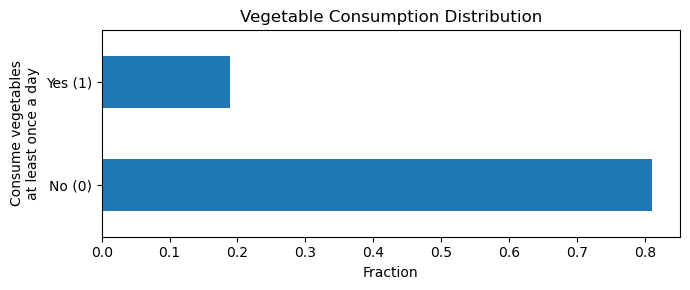

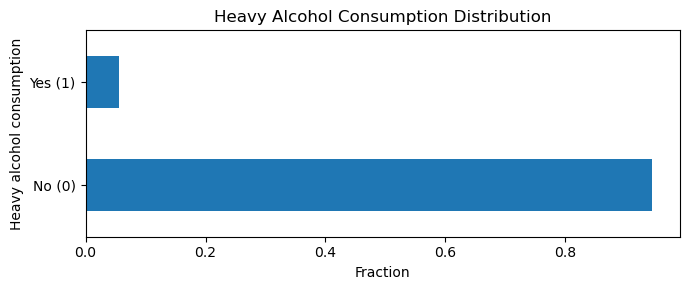

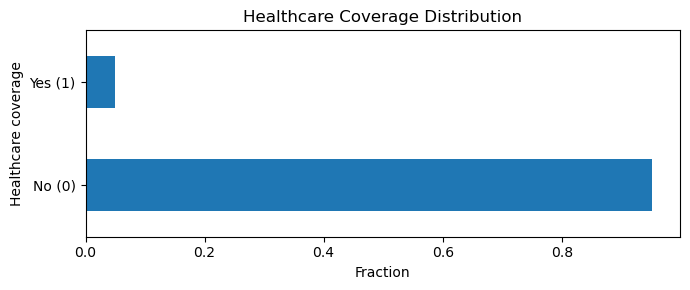

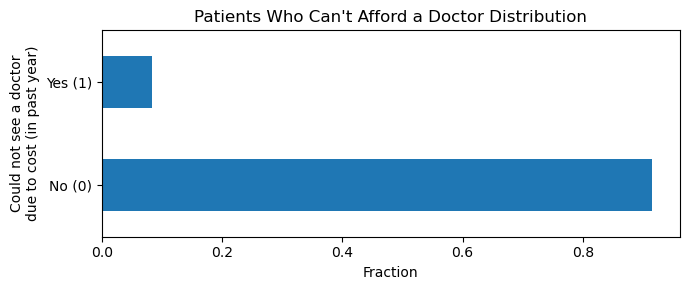

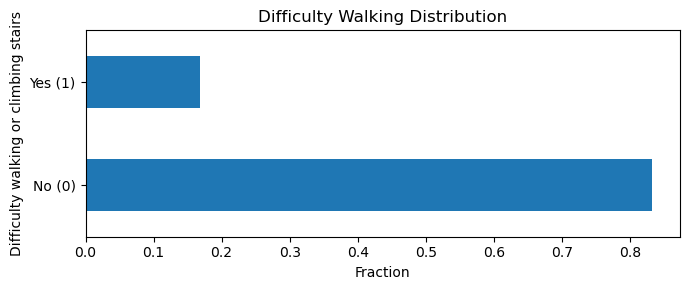

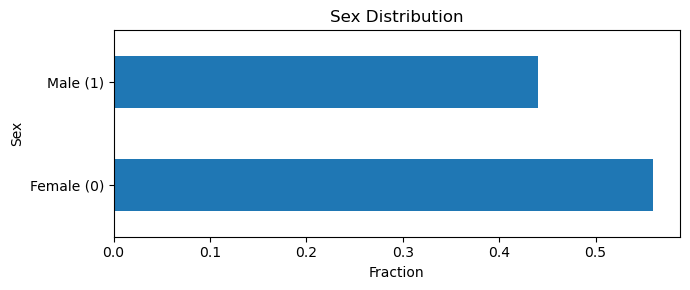

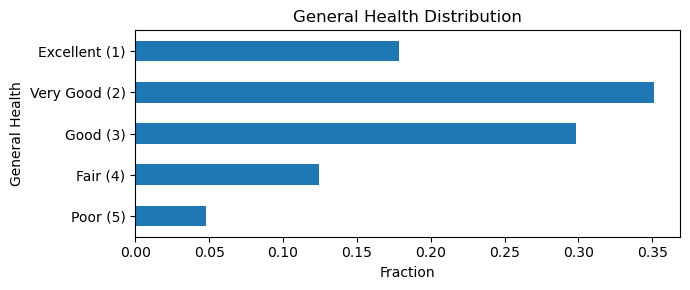

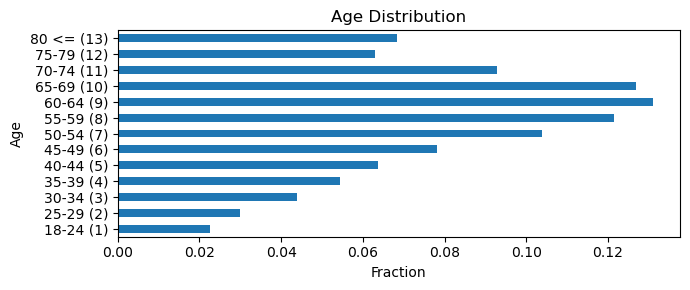

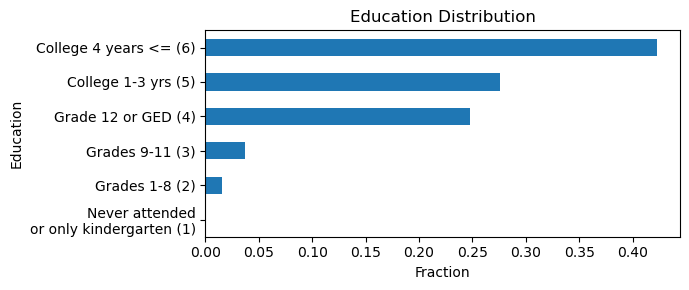

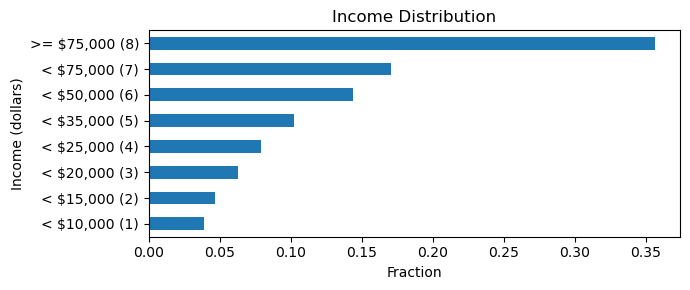

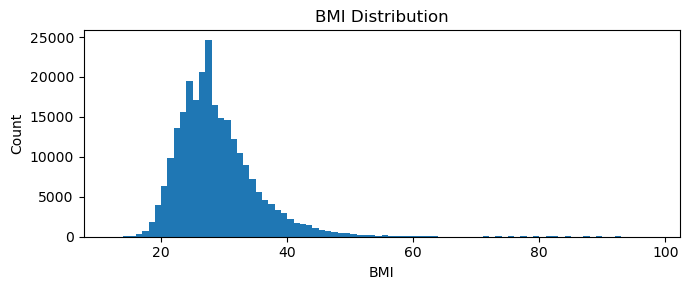

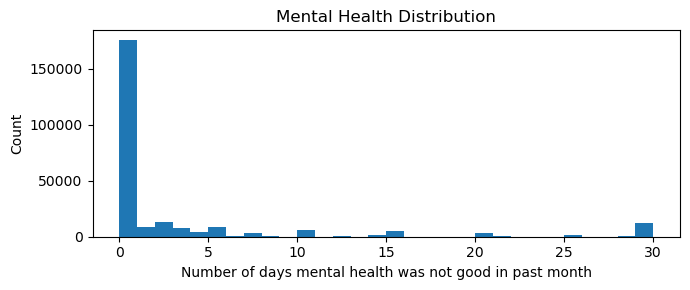

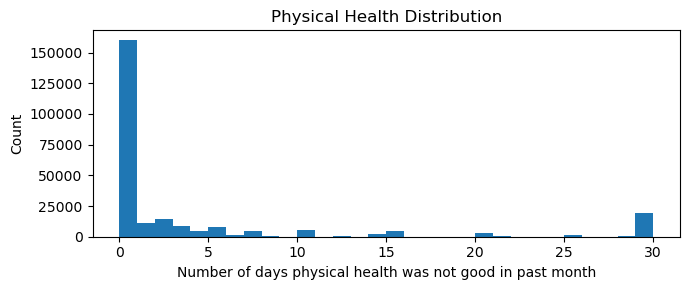

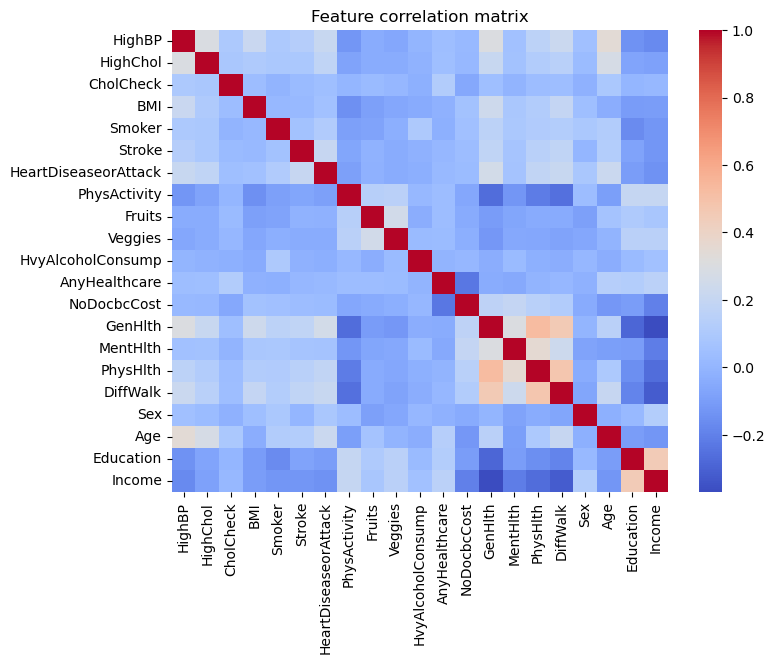

In [7]:
import seaborn as sns
# visualize target variable
plt.figure(figsize=(7,3))
df['Diabetes_012'].value_counts(normalize=True).reindex([0,1,2]).plot.barh()
plt.xlabel('Fraction')
plt.yticks([0,1,2], ['No diabetes (0)', 'Prediabetes (1)', 'Diabetes (2)'])
plt.ylabel('Diabetes status')
plt.title('Diabetes Outcome Distribution')
plt.tight_layout() 
plt.savefig("target_variable.jpg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

# visualize all other features
# HighBP
plt.figure(figsize=(7,3))
df['HighBP'].value_counts(normalize=True).plot.barh()
plt.xlabel('Fraction')
plt.yticks([0,1], ['No (0)', 'Yes (1)'])
plt.ylabel('High blood pressure presense')
plt.title('High Blood Pressure Presence Distribution')
plt.tight_layout() 
plt.show()

# HighChol
plt.figure(figsize=(7,3))
df['HighChol'].value_counts(normalize=True).plot.barh()
plt.xlabel('Fraction')
plt.yticks([0,1], ['No (0)', 'Yes (1)'])
plt.ylabel('High cholesterol presence')
plt.title('High Cholesterol Presence Distribution')
plt.tight_layout() 
plt.show()

# CholCheck
plt.figure(figsize=(7,3))
df['CholCheck'].value_counts(normalize=True).plot.barh()
plt.xlabel('Fraction')
plt.yticks([0,1], ['No (0)', 'Yes (1)'])
plt.ylabel('Cholesterol check\n(in past 5 years)')
plt.title('Cholesterol Check Distribution')
plt.tight_layout() 
plt.show()

# Smoker
plt.figure(figsize=(7,3))
df['Smoker'].value_counts(normalize=True).plot.barh()
plt.xlabel('Fraction')
plt.yticks([0,1], ['No (0)', 'Yes (1)'])
plt.ylabel('Smoker\n(at least 100 cigs in lifetime)')
plt.title('Smoker Distribution')
plt.tight_layout() 
plt.show()

# Stroke
plt.figure(figsize=(7,3))
df['Stroke'].value_counts(normalize=True).plot.barh()
plt.xlabel('Fraction')
plt.yticks([0,1], ['No (0)', 'Yes (1)'])
plt.ylabel('Stroke')
plt.title('Stroke Distribution')
plt.tight_layout() 
plt.show()

# HeartDiseaseorAttack
plt.figure(figsize=(7,3))
df['HeartDiseaseorAttack'].value_counts(normalize=True).plot.barh()
plt.xlabel('Fraction')
plt.yticks([0,1], ['No (0)', 'Yes (1)'])
plt.ylabel('Instance of coronary heart disease\nor myocardial infarction')
plt.title('Instance of Heart Disease/Attack Distribution')
plt.tight_layout() 
plt.show()

# PhysActivity
plt.figure(figsize=(7,3))
df['PhysActivity'].value_counts(normalize=True).plot.barh()
plt.xlabel('Fraction')
plt.yticks([0,1], ['No (0)', 'Yes (1)'])
plt.ylabel('Physical activity\nin past 30 days')
plt.title('Physical Activity Distribution')
plt.tight_layout() 
plt.show()

# Fruits
plt.figure(figsize=(7,3))
df['Fruits'].value_counts(normalize=True).plot.barh()
plt.xlabel('Fraction')
plt.yticks([0,1], ['No (0)', 'Yes (1)'])
plt.ylabel('Consume fruit\nat least once a day')
plt.title('Fruit Consumption Distribution')
plt.tight_layout() 
plt.show()

# Veggies
plt.figure(figsize=(7,3))
df['Veggies'].value_counts(normalize=True).plot.barh()
plt.xlabel('Fraction')
plt.yticks([0,1], ['No (0)', 'Yes (1)'])
plt.ylabel('Consume vegetables\nat least once a day')
plt.title('Vegetable Consumption Distribution')
plt.tight_layout() 
plt.show()

# HvyAlcoholConsump
plt.figure(figsize=(7,3))
df['HvyAlcoholConsump'].value_counts(normalize=True).plot.barh()
plt.xlabel('Fraction')
plt.yticks([0,1], ['No (0)', 'Yes (1)'])
plt.ylabel('Heavy alcohol consumption')
plt.title('Heavy Alcohol Consumption Distribution')
plt.tight_layout() 
plt.show()

# AnyHealthcare
plt.figure(figsize=(7,3))
df['AnyHealthcare'].value_counts(normalize=True).plot.barh()
plt.xlabel('Fraction')
plt.yticks([0,1], ['No (0)', 'Yes (1)'])
plt.ylabel('Healthcare coverage')
plt.title('Healthcare Coverage Distribution')
plt.tight_layout() 
plt.show()

# NoDocbcCost
plt.figure(figsize=(7,3))
df['NoDocbcCost'].value_counts(normalize=True).plot.barh()
plt.xlabel('Fraction')
plt.yticks([0,1], ['No (0)', 'Yes (1)'])
plt.ylabel('Could not see a doctor\ndue to cost (in past year)')
plt.title('Patients Who Can\'t Afford a Doctor Distribution')
plt.tight_layout() 
plt.show()

# DiffWalk
plt.figure(figsize=(7,3))
df['DiffWalk'].value_counts(normalize=True).plot.barh()
plt.xlabel('Fraction')
plt.yticks([0,1], ['No (0)', 'Yes (1)'])
plt.ylabel('Difficulty walking or climbing stairs')
plt.title('Difficulty Walking Distribution')
plt.tight_layout() 
plt.show()

# Sex
plt.figure(figsize=(7,3))
df['Sex'].value_counts(normalize=True).plot.barh()
plt.xlabel('Fraction')
plt.yticks([0,1], ['Female (0)', 'Male (1)'])
plt.ylabel('Sex')
plt.title('Sex Distribution')
plt.tight_layout() 
plt.show()

# GenHlth
plt.figure(figsize=(7,3))
df['GenHlth'].value_counts(normalize=True).reindex([5,4,3,2,1]).plot.barh()
plt.xlabel('Fraction')
plt.yticks([0, 1, 2, 3, 4], ['Poor (5)', 'Fair (4)', 'Good (3)', 'Very Good (2)', 'Excellent (1)'])
plt.ylabel('General Health')
plt.title('General Health Distribution')
plt.tight_layout() 
plt.show()

# Age
plt.figure(figsize=(7,3))
df['Age'].value_counts(normalize=True).reindex([1,2,3,4,5,6,7,8,9,10,11,12,13]).plot.barh()
plt.xlabel('Fraction')
plt.yticks([0,1,2,3,4,5,6,7,8,9,10,11,12], ['18-24 (1)', '25-29 (2)', '30-34 (3)', '35-39 (4)', 
                                            '40-44 (5)', '45-49 (6)', '50-54 (7)', '55-59 (8)', '60-64 (9)', 
                                            '65-69 (10)', '70-74 (11)', '75-79 (12)', '80 <= (13)'])
plt.ylabel('Age')
plt.title('Age Distribution')
plt.tight_layout() 
plt.show()

# Education
plt.figure(figsize=(7,3))
df['Education'].value_counts(normalize=True).reindex([1,2,3,4,5,6]).plot.barh()
plt.xlabel('Fraction')
plt.yticks([0,1,2,3,4,5], ['Never attended\nor only kindergarten (1)', 'Grades 1-8 (2)', 'Grades 9-11 (3)', 
                           'Grade 12 or GED (4)', 'College 1-3 yrs (5)', 'College 4 years <= (6)'])
plt.ylabel('Education')
plt.title('Education Distribution')
plt.tight_layout() 
plt.show()

# Income
plt.figure(figsize=(7,3))
df['Income'].value_counts(normalize=True).reindex([1,2,3,4,5,6,7,8]).plot.barh()
plt.xlabel('Fraction')
plt.yticks([0,1,2,3,4,5,6,7], ['< $10,000 (1)', '< $15,000 (2)', '< $20,000 (3)', 
                               '< $25,000 (4)', '< $35,000 (5)', '< $50,000 (6)', 
                               '< $75,000 (7)', '>= $75,000 (8)'])
plt.ylabel('Income (dollars)')
plt.title('Income Distribution')
plt.tight_layout() 
plt.show()

# BMI
plt.figure(figsize=(7,3))
df['BMI'].plot.hist(bins=np.arange(int(np.min(df['BMI'])), int(np.max(df['BMI'])) + 1, 1))
plt.xlabel('BMI')
plt.ylabel('Count')
plt.title('BMI Distribution')
plt.tight_layout()
plt.show()

# MentHlth
plt.figure(figsize=(7,3))
df['MentHlth'].plot.hist(bins=np.arange(int(np.min(df['MentHlth'])), int(np.max(df['MentHlth'])) + 1, 1))
plt.xlabel('Number of days mental health was not good in past month')
plt.ylabel('Count')
plt.title('Mental Health Distribution')
plt.tight_layout()
plt.show()

# PhysHlth
plt.figure(figsize=(7,3))
df['PhysHlth'].plot.hist(bins=np.arange(int(np.min(df['PhysHlth'])), int(np.max(df['PhysHlth'])) + 1, 1))
plt.xlabel('Number of days physical health was not good in past month')
plt.ylabel('Count')
plt.title('Physical Health Distribution')
plt.tight_layout()
plt.show()

# correlation matrix
corr = X.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title("Feature correlation matrix")
plt.savefig("../figures/correlation_matrix.jpg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

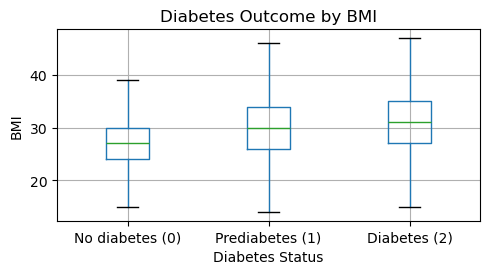

Diabetes_012       0     1      2
HighBP                           
0             134391  1718   8742
1              79312  2913  26604
Diabetes_012         0         1         2
HighBP                                    
0             0.927788  0.011860  0.060352
1             0.728776  0.026767  0.244457


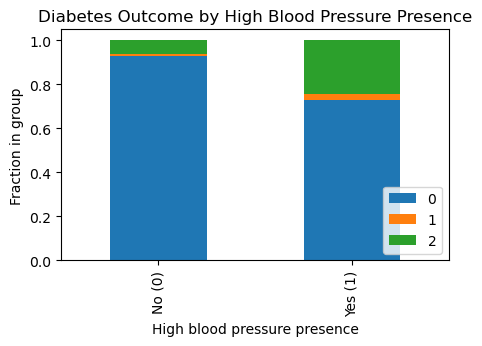

Diabetes_012       0     1      2
HighChol                         
0             132673  1756  11660
1              81030  2875  23686
Diabetes_012         0         1         2
HighChol                                  
0             0.908166  0.012020  0.079814
1             0.753130  0.026722  0.220149


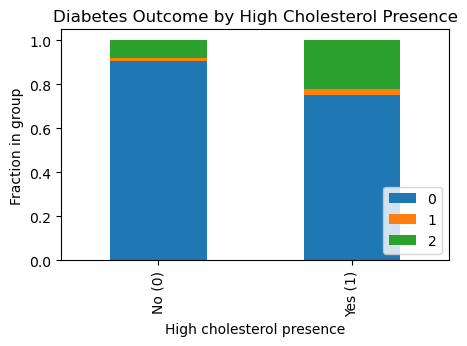

Diabetes_012      0    1     2
Age                           
1              5601   21    78
2              7404   54   140
3             10737   72   314
4             13055  142   626
5             14943  163  1051
6             17765  312  1742
7             22808  418  3088
8             26019  550  4263
9             26809  702  5733
10            24939  697  6558
11            17790  602  5141
12            12132  445  3403
13            13701  453  3209
Diabetes_012         0         1         2
Age                                       
1             0.982632  0.003684  0.013684
2             0.974467  0.007107  0.018426
3             0.965297  0.006473  0.028230
4             0.944440  0.010273  0.045287
5             0.924862  0.010089  0.065049
6             0.896362  0.015742  0.087895
7             0.866763  0.015885  0.117352
8             0.843896  0.017839  0.138265
9             0.806431  0.021117  0.172452
10            0.774647  0.021650  0.203703
11            0.755

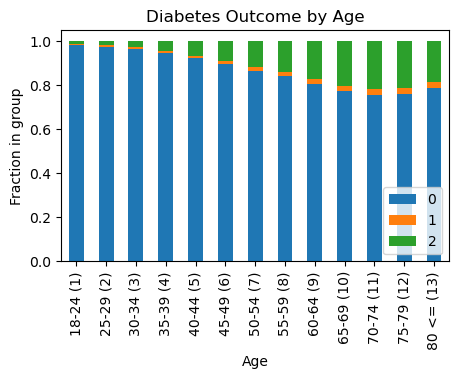

In [25]:
# BMI vs Diabetes_012 (removed outliers)
df[['BMI','Diabetes_012']].boxplot(by='Diabetes_012',figsize=(5,3),showfliers=False)
plt.title('')
plt.suptitle('')
plt.ylabel('BMI')
plt.xlabel('Diabetes Status')
plt.xticks([1,2,3], ['No diabetes (0)', 'Prediabetes (1)', 'Diabetes (2)'])
plt.title('Diabetes Outcome by BMI')
plt.tight_layout()
plt.savefig("BMI_vs_Diabetes.jpg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

# HighBP vs Diabetes_012
count_matrix = df.groupby(['HighBP', 'Diabetes_012']).size().unstack()
print(count_matrix)
count_matrix_norm = count_matrix.div(count_matrix.sum(axis=1),axis=0)
print(count_matrix_norm)
count_matrix_norm.plot(kind='bar', stacked=True,figsize=(5,3))
plt.ylabel('Fraction in group')
plt.xlabel('High blood pressure presence')
plt.xticks([0,1], ['No (0)', 'Yes (1)'])
plt.title('Diabetes Outcome by High Blood Pressure Presence')
plt.legend(loc=4)
plt.savefig("BP_vs_Diabetes.jpg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

# HighChol vs Diabetes_012
count_matrix = df.groupby(['HighChol', 'Diabetes_012']).size().unstack()
print(count_matrix)
count_matrix_norm = count_matrix.div(count_matrix.sum(axis=1),axis=0)
print(count_matrix_norm)
count_matrix_norm.plot(kind='bar', stacked=True,figsize=(5,3))
plt.ylabel('Fraction in group')
plt.xlabel('High cholesterol presence')
plt.xticks([0,1], ['No (0)', 'Yes (1)'])
plt.title('Diabetes Outcome by High Cholesterol Presence')
plt.legend(loc=4)
plt.show()

# Age vs Diabetes_012
count_matrix = df.groupby(['Age', 'Diabetes_012']).size().unstack()
print(count_matrix)
count_matrix_norm = count_matrix.div(count_matrix.sum(axis=1),axis=0)
print(count_matrix_norm)
count_matrix_norm.plot(kind='bar', stacked=True,figsize=(5,3))
plt.ylabel('Fraction in group')
plt.xlabel('Age')
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12], ['18-24 (1)', '25-29 (2)', '30-34 (3)', '35-39 (4)', 
                                            '40-44 (5)', '45-49 (6)', '50-54 (7)', '55-59 (8)', '60-64 (9)', 
                                            '65-69 (10)', '70-74 (11)', '75-79 (12)', '80 <= (13)'])
plt.title('Diabetes Outcome by Age')
plt.legend(loc=4)
plt.savefig("Age_vs_Diabetes.jpg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

## Models

#### Create ML pipeline function for reuse across different classification algorithms

In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC
import pickle

def ML_pipeline_classification(X, y, preprocessor, ML_algo, param_grid, percent_of_df):

    # extract the percent of the full dataset to use for this run
    if percent_of_df < 1.0:
        X, _, y, _ = train_test_split(X, y, train_size=percent_of_df,
                                      stratify=y, random_state=42)

    test_scores = []
    best_models = []
    test_sets = [] # save each random state's X_test, y_pred, and y_test
    feature_importance = None

    for i in range(3):
        print(f"Random state = {42*i}")

        # save 5% for test set
        # use stratify since dataset is imbalanced 
        X_other, X_test, y_other, y_test = train_test_split(X, y, test_size=0.05,
                                                            stratify=y,
                                                            random_state=42*i)
        kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42*i)

        pipe = make_pipeline(preprocessor, ML_algo)

        grid = GridSearchCV(pipe, param_grid=param_grid, scoring="f1_macro", cv=kf)
        grid.fit(X_other, y_other)
        
        # get the best model and save to best_models list
        best_model = grid.best_estimator_
        best_models.append(best_model)

        print("\tBest params:", grid.best_params_)

        # evaluate on test set
        y_pred = best_model.predict(X_test)
        scores = {
            "test_accuracy": accuracy_score(y_test, y_pred),
            "f1_macro": f1_score(y_test, y_pred, average="macro"),
            "f1_micro": f1_score(y_test, y_pred, average="micro"),
            "f1_weighted": f1_score(y_test, y_pred, average="weighted"),
        }
        test_scores.append(scores)
        print("\tTest accuracy:", scores["test_accuracy"])

        test_sets.append({"X_test": X_test, "y_test": y_test, "y_pred": y_pred})

        # get feature importance if logistic regr, RF, or XGBClassifier for last random state 
        if i == 2:
            if isinstance(ML_algo, RandomForestClassifier):
                feature_importance = best_model[-1].feature_importances_
            elif isinstance(ML_algo, LogisticRegression):
                coefs = best_model[-1].coef_ # shape is (num classes, num features)
                class_labels = best_model[-1].classes_ # get class names
                feature_importance = {'coef': coefs, 'class_labels': class_labels}
            elif isinstance(ML_algo, LinearSVC):
                coefs = best_model[-1].coef_
                class_labels = best_model[-1].classes_
                feature_importance = {"coef": coefs, "class_labels": class_labels}
                

    # print summary of scores
    accs = []
    f1_macros = []
    f1_micros = []
    f1_weighted = []
    for scores in test_scores:
        accs.append(scores["test_accuracy"])
        f1_macros.append(scores["f1_macro"])
        f1_micros.append(scores["f1_micro"])
        f1_weighted.append(scores["f1_weighted"])

    print("Mean test accuracy:", np.mean(accs))
    print("Std test accuracy:", np.std(accs))
    print("Mean f1 macro:", np.mean(f1_macros))
    print("Mean f1 micro:", np.mean(f1_micros))
    print("Mean f1 weighted:", np.mean(f1_weighted))

    return test_scores, best_models, test_sets, feature_importance


def save_model_data(filename, test_scores, best_models, test_sets, feature_importance):
    data = {
        "test_scores": test_scores,
        "best_models": best_models,
        "test_sets": test_sets,
        "feature_importance": feature_importance
    }
    
    file = open(filename, 'wb')
    pickle.dump(data, file)
    file.close()
    print(f"Saved data to {filename}")


def load_model_data(filename):
    file = open(filename, "rb")
    data = pickle.load(file)
    file.close()
    
    return (data["test_scores"],
            data["best_models"],
            data["test_sets"],
            data["feature_importance"])
    

### Logistic Regression

In [141]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

# perform initial run with just 10% of dataset
preprocessor = ColumnTransformer(
    transformers=[('std', StandardScaler(), X.columns)]
)

param_grid = {
    'logisticregression__penalty': ['l1', 'l2'], 
    'logisticregression__C': np.logspace(-3,3,7)
} 

ML_algo = LogisticRegression(solver="saga", max_iter=5000, random_state=42)

In [15]:
test_scores_10_lr, best_models_10_lr, test_sets_10_lr, feature_importance_10_lr = ML_pipeline_classification(
    X, y, preprocessor, ML_algo, param_grid, 0.1
)

# save model
save_model_data("../results/logreg_10.pkl", test_scores_10_lr, best_models_10_lr, test_sets_10_lr, feature_importance_10_lr)

# load model to test
test_scores, best_models, test_sets, feature_importances = load_model_data("../results/logreg_10.pkl")

print(test_scores)
print(best_models)
print(test_sets)
print(feature_importances)

Random state = 0
	Best params: {'logisticregression__C': np.float64(0.001), 'logisticregression__penalty': 'l2'}
	Test accuracy: 0.8408195429472025
Random state = 42
	Best params: {'logisticregression__C': np.float64(0.001), 'logisticregression__penalty': 'l2'}
	Test accuracy: 0.8573680063041765
Random state = 84
	Best params: {'logisticregression__C': np.float64(0.001), 'logisticregression__penalty': 'l2'}
	Test accuracy: 0.8479117415287628
Mean test accuracy: 0.8486997635933805
Std test accuracy: 0.006778822117448889
Mean f1 macro: 0.3781225277182692
Mean f1 micro: 0.8486997635933805
Mean f1 weighted: 0.8028809362729646
Saved data to ../results/logreg_10.pkl
[{'test_accuracy': 0.8408195429472025, 'f1_macro': 0.3622688282415969, 'f1_micro': 0.8408195429472025, 'f1_weighted': 0.7929944000304894}, {'test_accuracy': 0.8573680063041765, 'f1_macro': 0.4086702819268703, 'f1_micro': 0.8573680063041765, 'f1_weighted': 0.8188552665641511}, {'test_accuracy': 0.8479117415287628, 'f1_macro': 0.36

In [20]:
# try using 50% of dataset
test_scores_50_lr, best_models_50_lr, test_sets_50_lr, feature_importance_50_lr = ML_pipeline_classification(
    X, y, preprocessor, ML_algo, param_grid, 0.5
)

# save model
save_model_data("../results/logreg_50.pkl", test_scores_50_lr, best_models_50_lr, test_sets_50_lr, feature_importance_50_lr)


Random state = 0
	Best params: {'logisticregression__C': np.float64(1.0), 'logisticregression__penalty': 'l1'}
	Test accuracy: 0.8461053295490382
Random state = 42
	Best params: {'logisticregression__C': np.float64(0.01), 'logisticregression__penalty': 'l1'}
	Test accuracy: 0.8498896247240618
Random state = 84
	Best params: {'logisticregression__C': np.float64(0.01), 'logisticregression__penalty': 'l2'}
	Test accuracy: 0.8472090823084201
Mean test accuracy: 0.8477346788605066
Std test accuracy: 0.0015890062501661918
Mean f1 macro: 0.3972681993564637
Mean f1 micro: 0.8477346788605066
Mean f1 weighted: 0.8100302166883857
Saved data to ../results/logreg_50.pkl


In [142]:
# try using 100% of dataset
test_scores_100_lr, best_models_100_lr, test_sets_100_lr, feature_importance_100_lr = ML_pipeline_classification(
    X, y, preprocessor, ML_algo, param_grid, 1.0
)

# save model
save_model_data("../results/logreg_100.pkl", test_scores_100_lr, best_models_100_lr, test_sets_100_lr, feature_importance_100_lr)


Random state = 0
	Best params: {'logisticregression__C': np.float64(1.0), 'logisticregression__penalty': 'l2'}
	Test accuracy: 0.8479974771365499
Random state = 42
	Best params: {'logisticregression__C': np.float64(10.0), 'logisticregression__penalty': 'l1'}
	Test accuracy: 0.8453957742037213
Random state = 84
	Best params: {'logisticregression__C': np.float64(1.0), 'logisticregression__penalty': 'l1'}
	Test accuracy: 0.8524124881740776
Mean test accuracy: 0.8486019131714496
Std test accuracy: 0.0028962706970242767
Mean f1 macro: 0.3983849635594325
Mean f1 micro: 0.8486019131714496
Mean f1 weighted: 0.8108104183899506
Saved data to ../results/logreg_100.pkl


### Random Forest Classifier

In [130]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier

preprocessor = ColumnTransformer(
    transformers=[('std', StandardScaler(), X.columns)]
)

param_grid = {
    'randomforestclassifier__max_depth': [1, 3, 5, 10, 30],
    'randomforestclassifier__max_features': [0.1, 0.3, 0.5, 0.7]
}

ML_algo = RandomForestClassifier(n_estimators=100, random_state=42)

In [31]:
# try just using 10% of dataset
test_scores_10_rf, best_models_10_rf, test_sets_10_rf, feature_importance_10_rf = ML_pipeline_classification(
    X, y, preprocessor, ML_algo, param_grid, 0.1
)

# save model
save_model_data("../results/rfc_10.pkl", test_scores_10_rf, best_models_10_rf, test_sets_10_rf, feature_importance_10_rf)


Random state = 0
	Best params: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__max_features': 0.3}
	Test accuracy: 0.843183609141056
Random state = 42
	Best params: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__max_features': 0.5}
	Test accuracy: 0.8620961386918834
Random state = 84
	Best params: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__max_features': 0.5}
	Test accuracy: 0.8447596532702916
Mean test accuracy: 0.850013133701077
Std test accuracy: 0.008568167286735021
Mean f1 macro: 0.3905196388729637
Mean f1 micro: 0.850013133701077
Mean f1 weighted: 0.8082767409871732
Saved data to ../results/rfc_10.pkl


In [32]:
# try just using 50% of dataset
test_scores_50_rf, best_models_50_rf, test_sets_50_rf, feature_importance_50_rf = ML_pipeline_classification(
    X, y, preprocessor, ML_algo, param_grid, 0.5
)

# save model
save_model_data("../results/rfc_50.pkl", test_scores_50_rf, best_models_50_rf, test_sets_50_rf, feature_importance_50_rf)

Random state = 0
	Best params: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__max_features': 0.5}
	Test accuracy: 0.8494165878271839
Random state = 42
	Best params: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__max_features': 0.3}
	Test accuracy: 0.8530432040365815
Random state = 84
	Best params: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__max_features': 0.3}
	Test accuracy: 0.8513087354146956
Mean test accuracy: 0.8512561757594871
Std test accuracy: 0.001481026259182724
Mean f1 macro: 0.38592973311414863
Mean f1 micro: 0.8512561757594871
Mean f1 weighted: 0.8069183297390358
Saved data to ../results/rfc_50.pkl


In [131]:
# try just using 100% of dataset
test_scores_100_rf, best_models_100_rf, test_sets_100_rf, feature_importance_100_rf = ML_pipeline_classification(
    X, y, preprocessor, ML_algo, param_grid, 1.0
)

# save model
save_model_data("../results/rfc_100.pkl", test_scores_100_rf, best_models_100_rf, test_sets_100_rf, feature_importance_100_rf)

Random state = 0
	Best params: {'randomforestclassifier__max_depth': 30, 'randomforestclassifier__max_features': 0.7}
	Test accuracy: 0.8397193314411857
Random state = 42
	Best params: {'randomforestclassifier__max_depth': 30, 'randomforestclassifier__max_features': 0.7}
	Test accuracy: 0.8360138757489751
Random state = 84
	Best params: {'randomforestclassifier__max_depth': 30, 'randomforestclassifier__max_features': 0.7}
	Test accuracy: 0.8408230842005676
Mean test accuracy: 0.8388520971302428
Std test accuracy: 0.00205688972241661
Mean f1 macro: 0.4052126055930438
Mean f1 micro: 0.8388520971302428
Mean f1 weighted: 0.8095972942233934
Saved data to ../results/rfc_100.pkl


In [132]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier

# try class_weight=balanced with the whole df
preprocessor = ColumnTransformer(
    transformers=[('std', StandardScaler(), X.columns)]
)

param_grid = {
    'randomforestclassifier__max_depth': [1, 3, 5, 10, 30],
    'randomforestclassifier__max_features': [0.1, 0.3, 0.5, 0.7]
}

ML_algo = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)

test_scores_100_rf, best_models_100_rf, test_sets_100_rf, feature_importance_100_rf = ML_pipeline_classification(
    X, y, preprocessor, ML_algo, param_grid, 1.0
)

save_model_data("../results/rfc_weighted_100.pkl", test_scores_100_rf, best_models_100_rf, test_sets_100_rf, feature_importance_100_rf)


Random state = 0
	Best params: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__max_features': 0.1}
	Test accuracy: 0.6805424156417534
Random state = 42
	Best params: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__max_features': 0.1}
	Test accuracy: 0.6774676758120467
Random state = 84
	Best params: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__max_features': 0.1}
	Test accuracy: 0.6798328602964364
Mean test accuracy: 0.6792809839167456
Std test accuracy: 0.0013145168716913469
Mean f1 macro: 0.43152737519348766
Mean f1 micro: 0.6792809839167456
Mean f1 weighted: 0.7347877759274394
Saved data to ../results/rfc_weighted_100.pkl


### XGB Classifier
- Custom ml pipeline function is needed for XGB Classifier since we are using early stopping and can't use GridSearchCV

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

def ML_pipeline_xgbclassifier(X, y, param_grid, percent_of_df):
    # extract the percent of the full dataset to use for this run
    if percent_of_df < 1.0:
        X, _, y, _ = train_test_split(X, y, train_size=percent_of_df, stratify=y, random_state=42)

    test_scores = []
    best_models = []
    test_sets = []
    feature_importance = None

    for i in range(3):
        print(f"Random state = {42*i}")

        # 5% for test set
        X_other, X_test, y_other, y_test = train_test_split(X, y, test_size=0.05, stratify=y, random_state=42*i)

        kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42*i)

        best_mean_val_f1 = float("-inf")
        best_params = None
        best_model = None

        for params in ParameterGrid(param_grid):
            fold_val_f1s = []
            # manual loop for kfold
            for train_idx, val_idx in kf.split(X_other, y_other):

                X_train, X_val = X_other.iloc[train_idx], X_other.iloc[val_idx]
                y_train, y_val = y_other.iloc[train_idx], y_other.iloc[val_idx]

                # preprocess
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train)
                X_val_scaled = scaler.transform(X_val)

                # COMMENT OUT CLASS_WEIGHTS IF NOT WEIGHTED
                # class_weights = compute_sample_weight(class_weight="balanced", y=y_train)

                model = XGBClassifier(objective="multi:softprob", n_estimators=10000, random_state=42*i, **params, early_stopping_rounds=10)

                model.fit(X_train_scaled, y_train, eval_set=[(X_val_scaled, y_val)], verbose=False) #sample_weight=class_weights,

                # record fold val accuracy
                fold_val_f1s.append(f1_score(y_val, model.predict(X_val_scaled), average="macro"))

            mean_val_f1 = np.mean(fold_val_f1s)

            # update best params
            if mean_val_f1 > best_mean_val_f1:
                best_mean_val_f1 = mean_val_f1
                best_params = params

        print("\tBest params:", best_params)
        print("\tBest mean val f1 macro:", best_mean_val_f1)

        # now finally use best params to train final model
        X_train, X_val, y_train, y_val = train_test_split(X_other, y_other, test_size=0.33, 
                                                          stratify=y_other, random_state=42*i)

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        X_test_scaled = scaler.transform(X_test)

        # class_weights = compute_sample_weight("balanced", y=y_train)

        best_model = XGBClassifier(objective="multi:softprob", n_estimators=10000, random_state=42*i, **best_params, early_stopping_rounds=10)
        best_model.fit(X_train_scaled, y_train, eval_set=[(X_val_scaled, y_val)], verbose=False) # sample_weight=class_weights,
        
        # set feature_names so get_scores returns key:val pairs where the keys are the dataset's true feature names
        best_model.get_booster().feature_names = list(X.columns)
        best_models.append(best_model)

        # evaluate test set
        y_pred = best_model.predict(X_test_scaled)
        scores = {
            "test_accuracy": accuracy_score(y_test, y_pred),
            "f1_macro": f1_score(y_test, y_pred, average="macro"),
            "f1_micro": f1_score(y_test, y_pred, average="micro"),
            "f1_weighted": f1_score(y_test, y_pred, average="weighted"),
        }
        test_scores.append(scores)
        print("\tTest accuracy:", scores["test_accuracy"])
        print("\tF1 macro:", scores["f1_macro"])

        test_sets.append({"X_test": X_test_scaled, "y_test": y_test, "y_pred": y_pred})

        if i == 2:
            gain = best_model.get_booster().get_score(importance_type="gain")
            weight = best_model.get_booster().get_score(importance_type="weight")
            feature_importance = {"gain": gain, "weight": weight}
    
    # print summary of scores
    accs = []
    f1_macros = []
    f1_micros = []
    f1_weighted = []
    for scores in test_scores:
        accs.append(scores["test_accuracy"])
        f1_macros.append(scores["f1_macro"])
        f1_micros.append(scores["f1_micro"])
        f1_weighted.append(scores["f1_weighted"])

    print("Mean test accuracy:", np.mean(accs))
    print("Std test accuracy:", np.std(accs))
    print("Mean f1 macro:", np.mean(f1_macros))
    print("Std f1 macro:", np.std(f1_macros))
    print("Mean f1 micro:", np.mean(f1_micros))
    print("Mean f1 weighted:", np.mean(f1_weighted))

    return test_scores, best_models, test_sets, feature_importance

In [6]:
# weighted
param_grid = {"learning_rate": [0.03],
              "max_depth": [1, 3, 10, 30, 100],
              "colsample_bytree": [0.3, 0.9],              
              "subsample": [0.66]}

test_scores_100_xgb, best_models_100_xgb, test_sets_100_xgb, feature_importance_100_xgb = ML_pipeline_xgbclassifier(
    X, y, param_grid, 1.0
)

# save model
save_model_data("../results/xgbclassifier_100.pkl", test_scores_100_xgb, best_models_100_xgb,
                test_sets_100_xgb, feature_importance_100_xgb)


Random state = 0
	Best params: {'colsample_bytree': 0.3, 'learning_rate': 0.03, 'max_depth': 100, 'subsample': 0.66}
	Best mean val f1 macro: 0.44073941312048465
	Test accuracy: 0.7383317565436771
	F1 macro: 0.44325490040931753
Random state = 42
	Best params: {'colsample_bytree': 0.3, 'learning_rate': 0.03, 'max_depth': 30, 'subsample': 0.66}
	Best mean val f1 macro: 0.4404468928877454
	Test accuracy: 0.7385682749921161
	F1 macro: 0.43888785262462354
Random state = 84
	Best params: {'colsample_bytree': 0.3, 'learning_rate': 0.03, 'max_depth': 100, 'subsample': 0.66}
	Best mean val f1 macro: 0.4399205897192701
	Test accuracy: 0.7630873541469568
	F1 macro: 0.4448410986488593
Mean test accuracy: 0.74666246189425
Std test accuracy: 0.01161455407032873
Mean f1 macro: 0.44232795056093344
Std f1 macro: 0.002517235464066897
Mean f1 micro: 0.74666246189425
Mean f1 weighted: 0.775594627717945
Saved data to ../results/xgbclassifier_100.pkl


In [12]:
# unweighted
param_grid = {"learning_rate": [0.03],
              "max_depth": [1, 3, 10, 30, 100],
              "colsample_bytree": [0.3, 0.9],              
              "subsample": [0.66]}

test_scores_100_xgb, best_models_100_xgb, test_sets_100_xgb, feature_importance_100_xgb = ML_pipeline_xgbclassifier(
    X, y, param_grid, 1.0
)

# save model
save_model_data("../results/xgbclassifier_unweighted_100.pkl", test_scores_100_xgb, best_models_100_xgb,
                test_sets_100_xgb, feature_importance_100_xgb)


Random state = 0
	Best params: {'colsample_bytree': 0.9, 'learning_rate': 0.03, 'max_depth': 100, 'subsample': 0.66}
	Best mean val f1 macro: 0.4012911596041224
	Test accuracy: 0.8451592557552823
	F1 macro: 0.4022057233406575
Random state = 42
	Best params: {'colsample_bytree': 0.9, 'learning_rate': 0.03, 'max_depth': 3, 'subsample': 0.66}
	Best mean val f1 macro: 0.40071218713799156
	Test accuracy: 0.8504415011037527
	F1 macro: 0.4059554383454879
Random state = 84
	Best params: {'colsample_bytree': 0.9, 'learning_rate': 0.03, 'max_depth': 10, 'subsample': 0.66}
	Best mean val f1 macro: 0.3997598302424899
	Test accuracy: 0.8539892778303374
	F1 macro: 0.40875272435351323
Mean test accuracy: 0.8498633448964575
Std test accuracy: 0.00362794899922952
Mean f1 macro: 0.40563796201321956
Std f1 macro: 0.0026822128901022955
Mean f1 micro: 0.8498633448964575
Mean f1 weighted: 0.8142638189654655
Saved data to ../results/xgbclassifier_unweighted_100.pkl


### K Neighbors Classifier

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier

preprocessor = ColumnTransformer(
    transformers=[('std', StandardScaler(), X.columns)]
)

param_grid = {
    "kneighborsclassifier__n_neighbors": [1, 3, 5, 7, 9],
    "kneighborsclassifier__p": [1, 2], # manhattan distance vs. euclidean distance
    "kneighborsclassifier__weights": ["uniform", "distance"]
}

ML_algo = KNeighborsClassifier()

In [4]:
test_scores_100_knn, best_models_100_knn, test_sets_100_knn, feature_importance_100_knn = ML_pipeline_classification(
    X, y, preprocessor, ML_algo, param_grid, 1.0
)

# save model
save_model_data("../results/knn_100.pkl", test_scores_100_knn, best_models_100_knn, test_sets_100_knn, feature_importance_100_knn)

Random state = 0
	Best params: {'kneighborsclassifier__n_neighbors': 3, 'kneighborsclassifier__p': 2, 'kneighborsclassifier__weights': 'distance'}
	Test accuracy: 0.8111794386628823
Random state = 42
	Best params: {'kneighborsclassifier__n_neighbors': 3, 'kneighborsclassifier__p': 1, 'kneighborsclassifier__weights': 'distance'}
	Test accuracy: 0.8110217596972564
Random state = 84
	Best params: {'kneighborsclassifier__n_neighbors': 3, 'kneighborsclassifier__p': 1, 'kneighborsclassifier__weights': 'distance'}
	Test accuracy: 0.8095238095238095
Mean test accuracy: 0.8105750026279828
Std test accuracy: 0.0007460879620823224
Mean f1 macro: 0.406004312898758
Mean f1 micro: 0.8105750026279828
Mean f1 weighted: 0.7955040682195245
Saved data to ../results/knn_100.pkl


### Linear SVC

In [119]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.svm import LinearSVC

preprocessor = ColumnTransformer(
    transformers=[('std', StandardScaler(), X.columns)]
)

param_grid = {
    "linearsvc__C": [0.01, 0.1, 1, 10]
}

# remove class_weight for unweighted
ML_algo = LinearSVC(max_iter=5000, class_weight="balanced", random_state=42)

In [9]:
# try just using 10% of dataset
test_scores_10_linsvc, best_models_10_linsvc, test_sets_10_linsvc, feature_importance_10_linsvc = ML_pipeline_classification(
    X, y, preprocessor, ML_algo, param_grid, 0.1
)

# save model
save_model_data("../results/linsvc_10.pkl", test_scores_10_linsvc, best_models_10_linsvc, test_sets_10_linsvc, feature_importance_10_linsvc)

Random state = 0
	Best params: {'linearsvc__C': 0.1}
	Test accuracy: 0.8077226162332545
Random state = 42
	Best params: {'linearsvc__C': 10}
	Test accuracy: 0.8274231678486997
Random state = 84
	Best params: {'linearsvc__C': 0.01}
	Test accuracy: 0.8250591016548463
Mean test accuracy: 0.8200682952456001
Std test accuracy: 0.008782901758497774
Mean f1 macro: 0.4486072823354929
Mean f1 micro: 0.8200682952456001
Mean f1 weighted: 0.8177516993885213
Saved data to ../results/linsvc_10.pkl


In [10]:
# try just using 50% of dataset
test_scores_50_linsvc, best_models_50_linsvc, test_sets_50_linsvc, feature_importance_50_linsvc = ML_pipeline_classification(
    X, y, preprocessor, ML_algo, param_grid, 0.5
)

# save model
save_model_data("../results/linsvc_50.pkl", test_scores_50_linsvc, best_models_50_linsvc, test_sets_50_linsvc, feature_importance_50_linsvc)

Random state = 0
	Best params: {'linearsvc__C': 0.01}
	Test accuracy: 0.8170923998738568
Random state = 42
	Best params: {'linearsvc__C': 0.1}
	Test accuracy: 0.8235572374645223
Random state = 84
	Best params: {'linearsvc__C': 0.01}
	Test accuracy: 0.8144118574582151
Mean test accuracy: 0.8183538315988649
Std test accuracy: 0.003838654396407067
Mean f1 macro: 0.4477506228715722
Mean f1 micro: 0.8183538315988649
Mean f1 weighted: 0.8164449373101442
Saved data to ../results/linsvc_50.pkl


In [120]:
# try using the whole dataset
test_scores_100_linsvc, best_models_100_linsvc, test_sets_100_linsvc, feature_importance_100_linsvc = ML_pipeline_classification(
    X, y, preprocessor, ML_algo, param_grid, 1.0
)
# save model
save_model_data("../results/linsvc_weighted_100.pkl", test_scores_100_linsvc, best_models_100_linsvc,
                test_sets_100_linsvc, feature_importance_100_linsvc)
test_scores, _, _, _ = load_model_data("../results/linsvc_weighted_100.pkl")
print(test_scores)

Random state = 0
	Best params: {'linearsvc__C': 1}
	Test accuracy: 0.8221381267738883
Random state = 42
	Best params: {'linearsvc__C': 0.01}
	Test accuracy: 0.8187480290129296
Random state = 84
	Best params: {'linearsvc__C': 0.1}
	Test accuracy: 0.8250551876379691
Mean test accuracy: 0.8219804478082624
Std test accuracy: 0.0025772995521803036
Mean f1 macro: 0.4502462195898222
Mean f1 micro: 0.8219804478082624
Mean f1 weighted: 0.8190406103829652
Saved data to ../results/linsvc_weighted_100.pkl
[{'test_accuracy': 0.8221381267738883, 'f1_macro': 0.4492562718997705, 'f1_micro': 0.8221381267738883, 'f1_weighted': 0.8192649680361616}, {'test_accuracy': 0.8187480290129296, 'f1_macro': 0.44837743086887927, 'f1_micro': 0.8187480290129296, 'f1_weighted': 0.8162735348521362}, {'test_accuracy': 0.8250551876379691, 'f1_macro': 0.4531049560008166, 'f1_micro': 0.8250551876379691, 'f1_weighted': 0.8215833282605975}]


In [123]:
# try without class_weights
ML_algo = LinearSVC(max_iter=5000, random_state=42)

test_scores_100_linsvc, best_models_100_linsvc, test_sets_100_linsvc, feature_importance_100_linsvc = ML_pipeline_classification(
    X, y, preprocessor, ML_algo, param_grid, 1.0
)

# save model
save_model_data("../results/linsvc_unweighted_100.pkl", test_scores_100_linsvc, best_models_100_linsvc, test_sets_100_linsvc, feature_importance_100_linsvc)

Random state = 0
	Best params: {'linearsvc__C': 0.1}
	Test accuracy: 0.847445600756859
Random state = 42
	Best params: {'linearsvc__C': 0.1}
	Test accuracy: 0.8453957742037213
Random state = 84
	Best params: {'linearsvc__C': 0.1}
	Test accuracy: 0.8483916745506149
Mean test accuracy: 0.8470776831703984
Std test accuracy: 0.0012504338540281865
Mean f1 macro: 0.35906111879585884
Mean f1 micro: 0.8470776831703984
Mean f1 weighted: 0.7942813451501651
Saved data to ../results/linsvc_unweighted_100.pkl


## Results

### Confusion matrices

- LogisticRegression

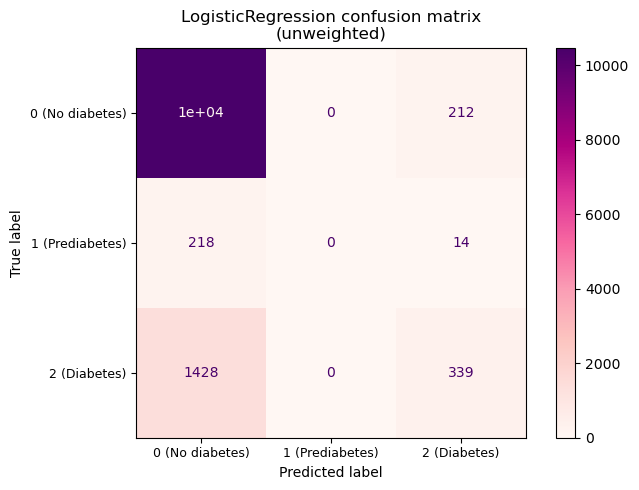

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
test_scores, best_models, test_sets, feature_importances = load_model_data("../results/logreg_100.pkl")

# get the test set from the last random state
last = test_sets[-1]
y_true = last["y_test"]
y_pred = last["y_pred"]
# create confusion matrix
cm = confusion_matrix(y_true,y_pred)
disp = ConfusionMatrixDisplay(cm,display_labels=['0 (No diabetes)', '1 (Prediabetes)', '2 (Diabetes)'])
fig, ax = plt.subplots(figsize=(7,5))
disp.plot(ax=ax, cmap="RdPu")
ax.set_title("LogisticRegression confusion matrix\n(unweighted)")
ax.tick_params(axis='both', labelsize=9)
plt.tight_layout()
plt.savefig("../figures/logreg_confmatrix.jpg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

- RandomForestClassifier

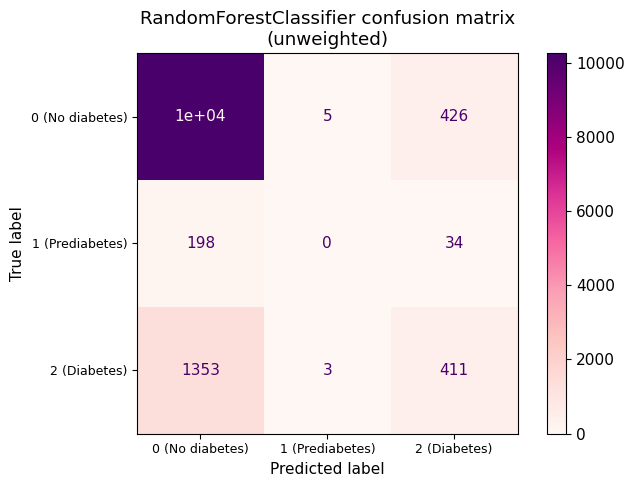

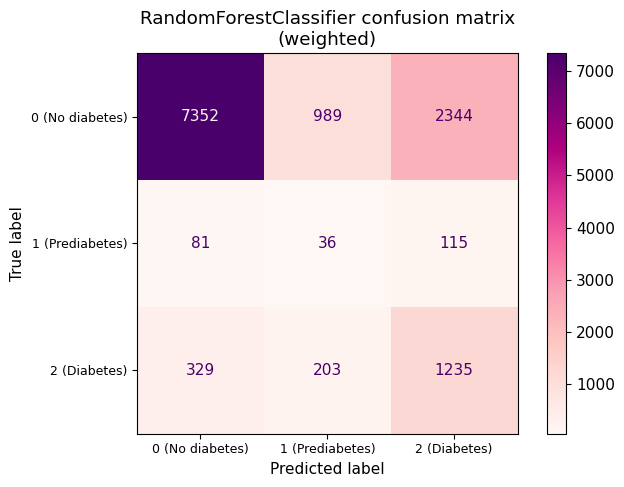

In [146]:
# unweighted
test_scores, best_models, test_sets, feature_importances = load_model_data("../results/rfc_100.pkl")
# get the test set from the last random state
last = test_sets[-1]
y_true = last["y_test"]
y_pred = last["y_pred"]
# create confusion matrix
cm = confusion_matrix(y_true,y_pred)
disp = ConfusionMatrixDisplay(cm,display_labels=['0 (No diabetes)', '1 (Prediabetes)', '2 (Diabetes)'])
fig, ax = plt.subplots(figsize=(7,5))
disp.plot(ax=ax, cmap="RdPu")
ax.set_title("RandomForestClassifier confusion matrix\n(unweighted)")
ax.tick_params(axis='both', labelsize=9)
plt.tight_layout()
plt.savefig("../figures/rfc_unweighted_confmatrix.jpg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

# weighted
test_scores, best_models, test_sets, feature_importances = load_model_data("../results/rfc_weighted_100.pkl")
# get the test set from the last random state
last = test_sets[-1]
y_true = last["y_test"]
y_pred = last["y_pred"]
# create confusion matrix
cm = confusion_matrix(y_true,y_pred)
disp = ConfusionMatrixDisplay(cm,display_labels=['0 (No diabetes)', '1 (Prediabetes)', '2 (Diabetes)'])
fig, ax = plt.subplots(figsize=(7,5))
disp.plot(ax=ax, cmap="RdPu")
ax.set_title("RandomForestClassifier confusion matrix\n(weighted)")
ax.tick_params(axis='both', labelsize=9)
plt.tight_layout()
plt.savefig("../figures/rfc_weighted_confmatrix.jpg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

- KNeighborsClassifier

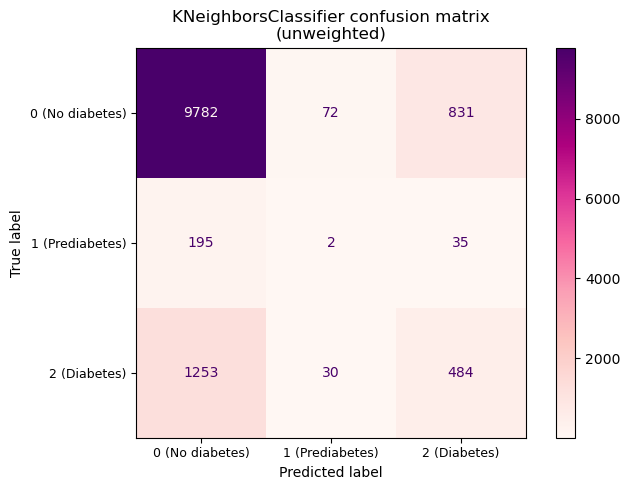

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_scores, best_models, test_sets, feature_importances = load_model_data("../results/knn_100.pkl")
# get the test set from the last random state
last = test_sets[-1]
y_true = last["y_test"]
y_pred = last["y_pred"]
# create confusion matrix
cm = confusion_matrix(y_true,y_pred)
disp = ConfusionMatrixDisplay(cm,display_labels=['0 (No diabetes)', '1 (Prediabetes)', '2 (Diabetes)'])
fig, ax = plt.subplots(figsize=(7,5))
disp.plot(ax=ax, cmap="RdPu")
ax.set_title("KNeighborsClassifier confusion matrix\n(unweighted)")
ax.tick_params(axis='both', labelsize=9)
plt.tight_layout()
plt.savefig("../figures/knn_confmatrix.jpg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

- Linear SVC

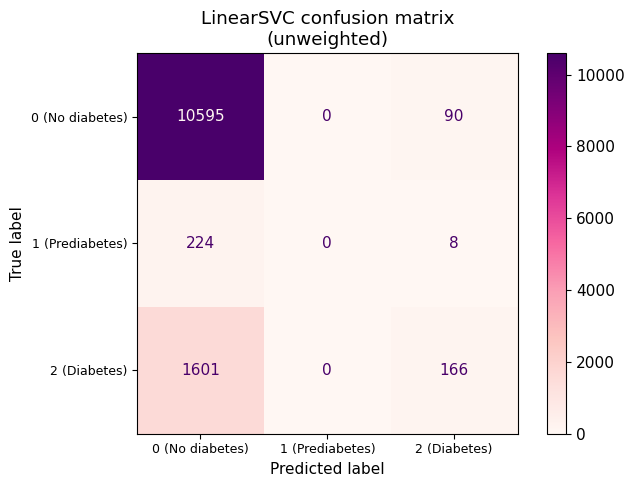

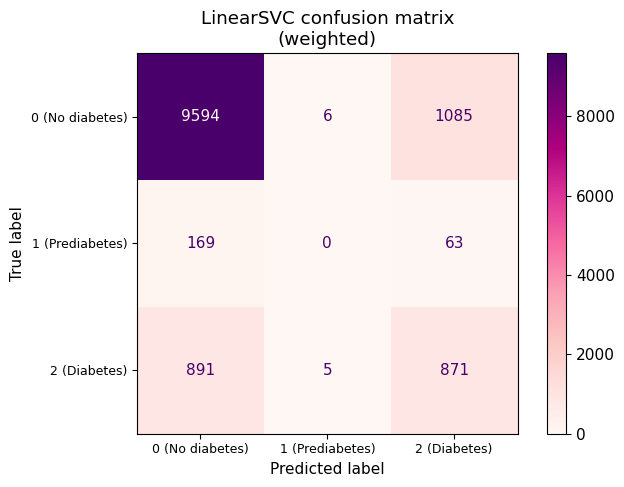

In [168]:
# unweighted
test_scores, best_models, test_sets, feature_importances = load_model_data("../results/linsvc_unweighted_100.pkl")
# get the test set from the last random state
last = test_sets[-1]
y_true = last["y_test"]
y_pred = last["y_pred"]
# create confusion matrix
cm = confusion_matrix(y_true,y_pred)
disp = ConfusionMatrixDisplay(cm,display_labels=['0 (No diabetes)', '1 (Prediabetes)', '2 (Diabetes)'])
fig, ax = plt.subplots(figsize=(7,5))
disp.plot(ax=ax, cmap="RdPu")
ax.set_title("LinearSVC confusion matrix\n(unweighted)")
ax.tick_params(axis='both', labelsize=9)
plt.tight_layout()
plt.savefig("../figures/linsvc_unweighted_confmatrix.jpg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

# weighted
test_scores, best_models, test_sets, feature_importances = load_model_data("../results/linsvc_weighted_100.pkl")
# get the test set from the last random state
last = test_sets[-1]
y_true = last["y_test"]
y_pred = last["y_pred"]
# create confusion matrix
cm = confusion_matrix(y_true,y_pred)
disp = ConfusionMatrixDisplay(cm,display_labels=['0 (No diabetes)', '1 (Prediabetes)', '2 (Diabetes)'])
fig, ax = plt.subplots(figsize=(7,5))
disp.plot(ax=ax, cmap="RdPu")
ax.set_title("LinearSVC confusion matrix\n(weighted)")
ax.tick_params(axis='both', labelsize=9)
plt.tight_layout()
plt.savefig("../figures/linsvc_weighted_confmatrix.jpg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

- XGBClassifier

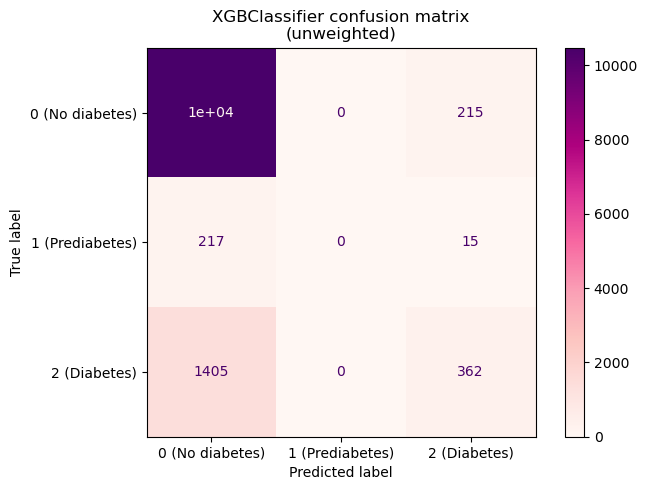

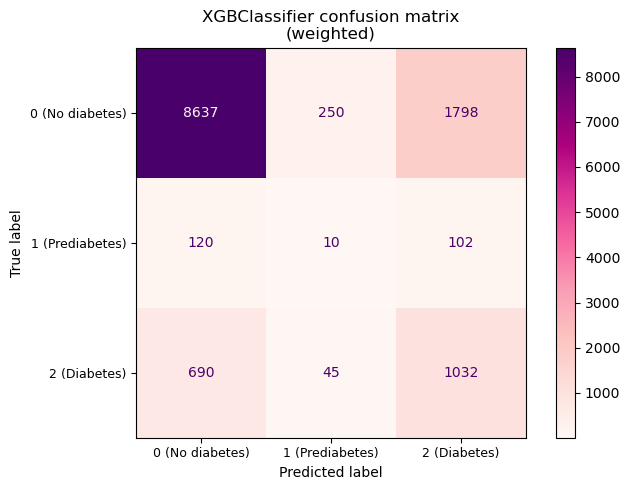

In [14]:
# unweighted
test_scores, best_models, test_sets, feature_importances = load_model_data("../results/xgbclassifier_unweighted_100.pkl")

# get the test set from the last random state
last = test_sets[-1]
y_true = last["y_test"]
y_pred = last["y_pred"]
# create confusion matrix
cm = confusion_matrix(y_true,y_pred)
disp = ConfusionMatrixDisplay(cm,display_labels=['0 (No diabetes)', '1 (Prediabetes)', '2 (Diabetes)'])
fig, ax = plt.subplots(figsize=(7,5))
disp.plot(ax=ax, cmap="RdPu")
ax.set_title("XGBClassifier confusion matrix\n(unweighted)")
plt.tight_layout()
plt.savefig("../figures/xgb_unweighted_confmatrix.jpg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

# weighted
test_scores, best_models, test_sets, feature_importances = load_model_data("../results/xgbclassifier_100.pkl")

# get the test set from the last random state
last = test_sets[-1]
y_true = last["y_test"]
y_pred = last["y_pred"]
# create confusion matrix
cm = confusion_matrix(y_true,y_pred)
disp = ConfusionMatrixDisplay(cm,display_labels=['0 (No diabetes)', '1 (Prediabetes)', '2 (Diabetes)'])
fig, ax = plt.subplots(figsize=(7,5))
disp.plot(ax=ax, cmap="RdPu")
ax.set_title("XGBClassifier confusion matrix\n(weighted)")
ax.tick_params(axis='both', labelsize=9)
plt.tight_layout()
plt.savefig("../figures/xgb_weighted_confmatrix.jpg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

### Model test scores

In [15]:
from sklearn.metrics import f1_score
import numpy as np

# doesn't matter which file we use since we split the dataset the same way for all 
# (y_test equivalent across models for each rs)
_, _, test_sets, _ = load_model_data("../results/logreg_100.pkl")

accs = []
f1_macros = []
f1_micros = []
f1_weighted = []

for t in test_sets:
    y_test = t["y_test"]

    # we always predict class 0
    y_pred_baseline = np.zeros(y_test.shape)

    accs.append(np.sum(y_test == 0)/len(y_test))
    f1_macros.append(f1_score(y_test, y_pred_baseline, average="macro"))
    f1_micros.append(f1_score(y_test, y_pred_baseline, average="micro"))
    f1_weighted.append(f1_score(y_test, y_pred_baseline, average="weighted"))

baseline_mean = np.mean(accs)
baseline_std = np.std(accs)
baseline_f1_macro_mean = np.mean(f1_macros)
baseline_f1_micro_mean = np.mean(f1_micros)
baseline_f1_weighted_mean = np.mean(f1_weighted)
baseline_f1_macro_std = np.std(f1_macros)
baseline_f1_micro_std = np.std(f1_micros)
baseline_f1_weighted_std = np.std(f1_weighted)

print(f"Baseline accuracy: {baseline_mean} +/- {baseline_std}")
print(f"Baseline F1 macro: {baseline_f1_macro_mean} +/- {baseline_f1_macro_std}")
print(f"Baseline F1 micro: {baseline_f1_micro_mean} +/- {baseline_f1_micro_std}")
print(f"Baseline F1 weighted: {baseline_f1_weighted_mean} +/- {baseline_f1_weighted_std}")

Baseline accuracy: 0.8423998738568276 +/- 1.1102230246251565e-16
Baseline F1 macro: 0.3048197754860428 +/- 0.0
Baseline F1 micro: 0.8423998738568276 +/- 1.1102230246251565e-16
Baseline F1 weighted: 0.7703404212555268 +/- 1.1102230246251565e-16


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# helper function to get means and stds of test accuracies for each model we trained
def get_mean_and_std(filename, metric):
    test_scores, _, _, _ = load_model_data(filename)
    vals = []
    for scores in test_scores:
        vals.append(scores[metric])
    return np.mean(vals), np.std(vals)

model_acc_scores = {
    "LogisticRegression": get_mean_and_std("../results/logreg_100.pkl", "test_accuracy"),
    "KNeighborsClassifier": get_mean_and_std("../results/knn_100.pkl", "test_accuracy"),
    "RandomForest--unweighted": get_mean_and_std("../results/rfc_100.pkl", "test_accuracy"),
    "RandomForest--weighted": get_mean_and_std("../results/rfc_weighted_100.pkl", "test_accuracy"),
    "XGB--unweighted": get_mean_and_std("../results/xgbclassifier_unweighted_100.pkl", "test_accuracy"),
    "XGB--weighted": get_mean_and_std("../results/xgbclassifier_100.pkl", "test_accuracy"),
    "LinearSVC--unweighted": get_mean_and_std("../results/linsvc_unweighted_100.pkl", "test_accuracy"),
    "LinearSVC--weighted": get_mean_and_std("../results/linsvc_weighted_100.pkl", "test_accuracy"),
    "Baseline": (baseline_mean, baseline_std)
}

model_f1_macro = {
    "LogisticRegression": get_mean_and_std("../results/logreg_100.pkl", "f1_macro"),
    "KNeighborsClassifier": get_mean_and_std("../results/knn_100.pkl", "f1_macro"),
    "RandomForest--unweighted": get_mean_and_std("../results/rfc_100.pkl", "f1_macro"),
    "RandomForest--weighted": get_mean_and_std("../results/rfc_weighted_100.pkl", "f1_macro"),
    "XGB--unweighted": get_mean_and_std("../results/xgbclassifier_unweighted_100.pkl", "f1_macro"),
    "XGB--weighted": get_mean_and_std("../results/xgbclassifier_100.pkl", "f1_macro"),
    "LinearSVC--unweighted": get_mean_and_std("../results/linsvc_unweighted_100.pkl", "f1_macro"),
    "LinearSVC--weighted": get_mean_and_std("../results/linsvc_weighted_100.pkl", "f1_macro"),
    "Baseline": (baseline_f1_macro_mean, baseline_f1_macro_std)
}

model_f1_weighted = {
    "LogisticRegression": get_mean_and_std("../results/logreg_100.pkl", "f1_weighted"),
    "KNeighborsClassifier": get_mean_and_std("../results/knn_100.pkl", "f1_weighted"),
    "RandomForest--unweighted": get_mean_and_std("../results/rfc_100.pkl", "f1_weighted"),
    "RandomForest--weighted": get_mean_and_std("../results/rfc_weighted_100.pkl", "f1_weighted"),
    "XGB--unweighted": get_mean_and_std("../results/xgbclassifier_unweighted_100.pkl", "f1_weighted"),
    "XGB--weighted": get_mean_and_std("../results/xgbclassifier_100.pkl", "f1_weighted"),
    "LinearSVC--unweighted": get_mean_and_std("../results/linsvc_unweighted_100.pkl", "f1_weighted"),
    "LinearSVC--weighted": get_mean_and_std("../results/linsvc_weighted_100.pkl", "f1_weighted"),
    "Baseline": (baseline_f1_weighted_mean, baseline_f1_weighted_std)
}

# collect data for accuracy plot
models = list(model_acc_scores.keys())
means = []
stds = []
for model in models:
    means.append(model_acc_scores[model][0])
    stds.append(model_acc_scores[model][1])

# collect data for f1 macro plot
f1_macro_means = []
f1_macro_stds = []
for model in models:
    f1_macro_means.append(model_f1_macro[model][0])
    f1_macro_stds.append(model_f1_macro[model][1])

# collect data for f1 weighted plot
f1_weighted_means = []
f1_weighted_stds = []
for model in models:
    f1_weighted_means.append(model_f1_weighted[model][0])
    f1_weighted_stds.append(model_f1_weighted[model][1])

models: ['LogisticRegression', 'KNeighborsClassifier', 'RandomForest--unweighted', 'RandomForest--weighted', 'XGB--unweighted', 'XGB--weighted', 'LinearSVC--unweighted', 'LinearSVC--weighted', 'Baseline']
means: [np.float64(0.8486019131714496), np.float64(0.8105750026279828), np.float64(0.8388520971302428), np.float64(0.6792809839167456), np.float64(0.8498633448964575), np.float64(0.74666246189425), np.float64(0.8470776831703984), np.float64(0.8219804478082624), np.float64(0.8423998738568276)]
stds: [np.float64(0.0028962706970242767), np.float64(0.0007460879620823224), np.float64(0.00205688972241661), np.float64(0.0013145168716913469), np.float64(0.00362794899922952), np.float64(0.01161455407032873), np.float64(0.0012504338540281865), np.float64(0.0025772995521803036), np.float64(1.1102230246251565e-16)]


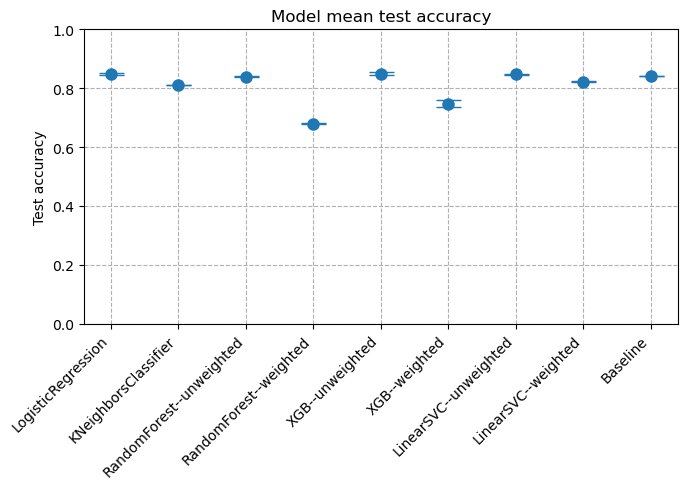

models: ['LogisticRegression', 'KNeighborsClassifier', 'RandomForest--unweighted', 'RandomForest--weighted', 'XGB--unweighted', 'XGB--weighted', 'LinearSVC--unweighted', 'LinearSVC--weighted', 'Baseline']
f1 macro means: [np.float64(0.3983849635594325), np.float64(0.406004312898758), np.float64(0.4052126055930438), np.float64(0.43152737519348766), np.float64(0.40563796201321956), np.float64(0.44232795056093344), np.float64(0.35906111879585884), np.float64(0.4502462195898222), np.float64(0.3048197754860428)]
f1 macro stds: [np.float64(0.0038913832693279076), np.float64(0.0008629322025594274), np.float64(0.003531296498121037), np.float64(0.00155356986339182), np.float64(0.0026822128901022955), np.float64(0.002517235464066897), np.float64(0.0029001373191571583), np.float64(0.002053025538086613), np.float64(0.0)]


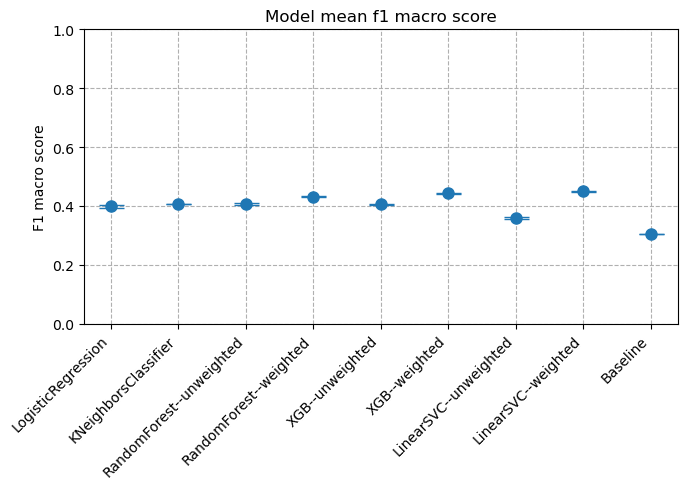

models: ['LogisticRegression', 'KNeighborsClassifier', 'RandomForest--unweighted', 'RandomForest--weighted', 'XGB--unweighted', 'XGB--weighted', 'LinearSVC--unweighted', 'LinearSVC--weighted', 'Baseline']
f1 weighted means: [np.float64(0.8108104183899506), np.float64(0.7955040682195245), np.float64(0.8095972942233934), np.float64(0.7347877759274394), np.float64(0.8142638189654655), np.float64(0.775594627717945), np.float64(0.7942813451501651), np.float64(0.8190406103829652), np.float64(0.7703404212555268)]
f1 weighted stds: [np.float64(0.0027202565761938607), np.float64(0.00013191950894896794), np.float64(0.002153485703609926), np.float64(0.0010573943692177951), np.float64(0.0026112060169847153), np.float64(0.006426081481865615), np.float64(0.0016143451987842119), np.float64(0.002173511563890081), np.float64(1.1102230246251565e-16)]


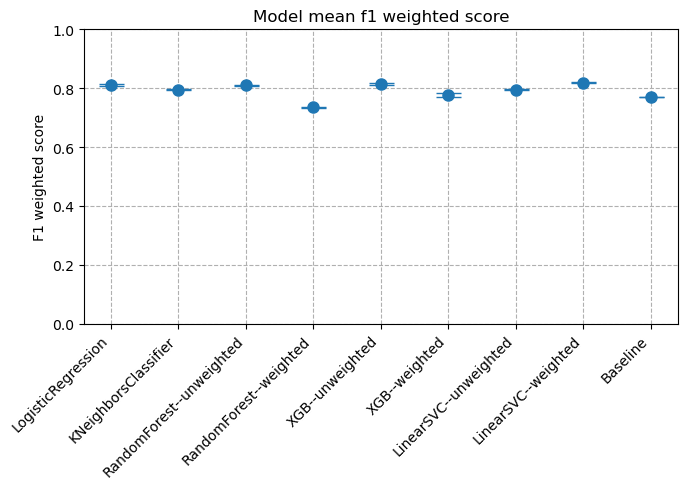

In [17]:
# accuracy
print("models:", models)
print("means:", means)
print("stds:", stds)
plt.figure(figsize=(7,5))
plt.errorbar(list(range(len(models))), means, yerr=stds, fmt='o', capsize=9, markersize=8)
plt.xticks(list(range(len(models))), models, rotation=45, ha="right")
plt.grid(linestyle='--')
plt.ylim(0, 1.0)
plt.ylabel("Test accuracy")
plt.title("Model mean test accuracy")
plt.tight_layout() 
plt.savefig("../figures/mean_std_accs.jpg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

# f1 macro
print("models:", models)
print("f1 macro means:", f1_macro_means)
print("f1 macro stds:", f1_macro_stds)
plt.figure(figsize=(7,5))
plt.errorbar(list(range(len(models))), f1_macro_means, yerr=f1_macro_stds, fmt='o', capsize=9, markersize=8)
plt.xticks(list(range(len(models))), models, rotation=45, ha="right")
plt.grid(linestyle='--')
plt.ylim(0, 1.0)
plt.ylabel("F1 macro score")
plt.title("Model mean f1 macro score")
plt.tight_layout() 
plt.savefig("../figures/mean_f1_macro.jpg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

# f1 weighted
print("models:", models)
print("f1 weighted means:", f1_weighted_means)
print("f1 weighted stds:", f1_weighted_stds)
plt.figure(figsize=(7,5))
plt.errorbar(list(range(len(models))), f1_weighted_means, yerr=f1_weighted_stds, fmt='o', capsize=9, markersize=8)
plt.xticks(list(range(len(models))), models, rotation=45, ha="right")
plt.grid(linestyle='--')
plt.ylim(0, 1.0)
plt.ylabel("F1 weighted score")
plt.title("Model mean f1 weighted score")
plt.tight_layout() 
plt.savefig("../figures/mean_f1_weighted.jpg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()


In [16]:
# print classification report for best model
from sklearn.metrics import classification_report

_, _, test_sets, _ = load_model_data("../results/linsvc_weighted_100.pkl")

# use last random state
last_set = test_sets[-1]
y_test = last_set["y_test"]
y_pred = last_set["y_pred"]

print(classification_report(y_test, y_pred, target_names=["No diabetes", "Prediabetes", "Diabetes"]))


              precision    recall  f1-score   support

 No diabetes       0.90      0.90      0.90     10685
 Prediabetes       0.00      0.00      0.00       232
    Diabetes       0.43      0.49      0.46      1767

    accuracy                           0.83     12684
   macro avg       0.44      0.46      0.45     12684
weighted avg       0.82      0.83      0.82     12684



### Feature importances

- permutation feature importances

f1_macro = 0.453
shuffling HighBP
   shuffled f1 macro score: 0.442 +/- 0.003
shuffling HighChol
   shuffled f1 macro score: 0.444 +/- 0.001
shuffling CholCheck
   shuffled f1 macro score: 0.452 +/- 0.0
shuffling BMI
   shuffled f1 macro score: 0.429 +/- 0.003
shuffling Smoker
   shuffled f1 macro score: 0.453 +/- 0.0
shuffling Stroke
   shuffled f1 macro score: 0.453 +/- 0.0
shuffling HeartDiseaseorAttack
   shuffled f1 macro score: 0.452 +/- 0.001
shuffling PhysActivity
   shuffled f1 macro score: 0.452 +/- 0.0
shuffling Fruits
   shuffled f1 macro score: 0.453 +/- 0.0
shuffling Veggies
   shuffled f1 macro score: 0.453 +/- 0.0
shuffling HvyAlcoholConsump
   shuffled f1 macro score: 0.451 +/- 0.0
shuffling AnyHealthcare
   shuffled f1 macro score: 0.453 +/- 0.0
shuffling NoDocbcCost
   shuffled f1 macro score: 0.454 +/- 0.001
shuffling GenHlth
   shuffled f1 macro score: 0.418 +/- 0.002
shuffling MentHlth
   shuffled f1 macro score: 0.454 +/- 0.001
shuffling PhysHlth
   shuffled f1 m

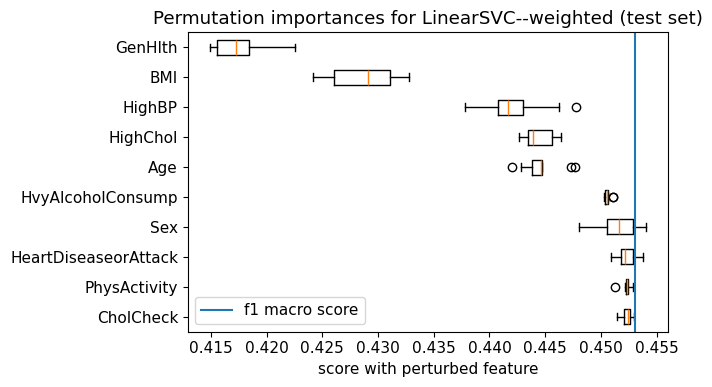

In [157]:
# calculate permutation feature importance linearsvc model (weighted)
import numpy as np
import matplotlib.pyplot as plt

test_scores, best_models, test_sets, feature_importances = load_model_data("../results/linsvc_weighted_100.pkl")
# use last random state's test set
last_set = test_sets[-1]
X_test_unpreproc = last_set["X_test"]
y_test = last_set["y_test"]

# get last random state's pipeline
pipeline = best_models[-1]
scaler = pipeline[0]
model = pipeline[1]

ftr_names = list(X.columns)
X_test_df = pd.DataFrame(X_test_unpreproc, columns=ftr_names)

# scale X_test
X_test_scaled = scaler.transform(X_test_df)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=ftr_names)

np.random.seed(42)
nr_runs = 10
scores = np.zeros([len(ftr_names),nr_runs])

test_score = f1_score(y_test, model.predict(X_test_scaled_df.values), average="macro")
print("f1_macro =", np.around(test_score, 3))

# loop through the features
for i in range(len(ftr_names)):
    print('shuffling '+str(ftr_names[i]))
    f1_scores = []
    for j in range(nr_runs):
        X_test_shuffled = X_test_scaled_df.copy()
        X_test_shuffled[ftr_names[i]] = np.random.permutation(X_test_shuffled[ftr_names[i]].values)
        y_pred = model.predict(X_test_shuffled.values)
        f1_scores.append(f1_score(y_test, y_pred, average="macro"))
    print('   shuffled f1 macro score:',np.around(np.mean(f1_scores),3),'+/-',np.around(np.std(f1_scores),3))
    scores[i] = f1_scores

# get 10 most important
sorted_idcs = np.argsort(np.mean(scores, axis=1))
top_10 = sorted_idcs[:10]
top_10 = top_10[::-1]

plt.rcParams.update({'font.size': 11})
plt.figure(figsize=(7,4))
plt.boxplot(scores[top_10].T,tick_labels=np.array(ftr_names)[top_10],vert=False)
plt.axvline(test_score,label='f1 macro score')
plt.title("Permutation importances for LinearSVC--weighted (test set)")
plt.xlabel('score with perturbed feature')
plt.legend()
plt.tight_layout()
plt.savefig("../figures/permut_linsvc_weighted.jpg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

- linearsvc coefficient feature importances

[-0.12661143 -0.10486646 -0.06472637 -0.15938504  0.00354193 -0.01104003
 -0.03296951  0.00764011  0.00723498  0.00600881  0.05303269 -0.00678252
 -0.0058032  -0.20110564  0.00762906  0.01787    -0.02447865 -0.04079849
 -0.13204758  0.01526603  0.04761135]


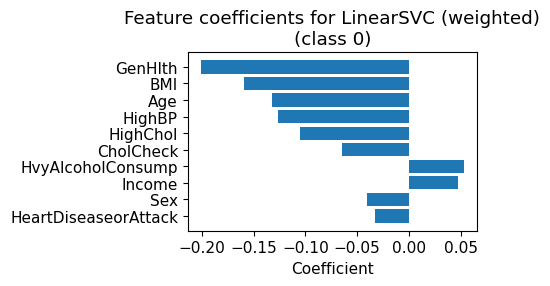

[ 0.04566491  0.08097724  0.03516962  0.0927563  -0.00488933 -0.01265042
 -0.01036441 -0.00349187 -0.00165373 -0.00612933 -0.00824712 -0.00614421
  0.03555109  0.07469742  0.02732061 -0.01270239 -0.00708634  0.00588104
  0.10260341 -0.02573783 -0.04374666]


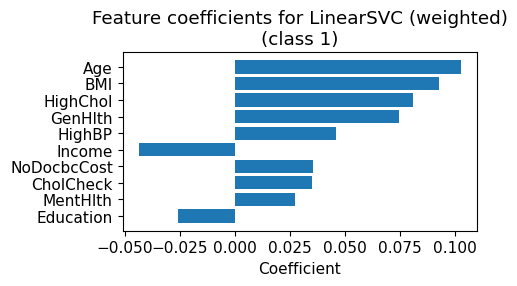

[ 0.12509465  0.09748964  0.06436416  0.15289245 -0.00304458  0.01348088
  0.03599684 -0.00754333 -0.00741857 -0.0053128  -0.0568991   0.0090351
 -0.00072453  0.20109135 -0.01319354 -0.01696396  0.02726433  0.04277421
  0.12139563 -0.01178246 -0.04259943]


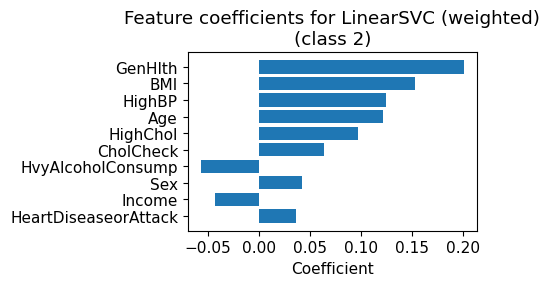

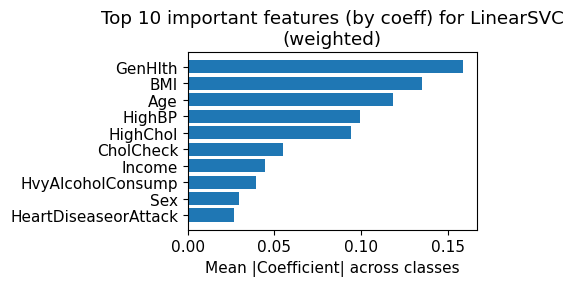

In [165]:
feature_names = X.columns
_, _, _, feature_importances = load_model_data("../results/linsvc_weighted_100.pkl")
coefs = feature_importances['coef']
for class_num in [0, 1, 2]:
    class_num_coefs = coefs[class_num]
    print(class_num_coefs)
    sorted_indcs = np.argsort(np.abs(class_num_coefs))

    plt.figure(figsize=(5,3))
    plt.rcParams.update({'font.size': 11})
    plt.barh(np.arange(10),class_num_coefs[sorted_indcs[-10:]])
    plt.yticks(np.arange(10),feature_names[sorted_indcs[-10:]])
    plt.xlabel('Coefficient')
    plt.title(f'Feature coefficients for LinearSVC (weighted)\n(class {class_num})')
    plt.tight_layout()
    plt.savefig(f"../figures/linsvc_coefs_{class_num}.jpg", dpi=300, bbox_inches="tight", transparent=True)
    plt.show()

overall_imprt = np.mean(np.abs(coefs), axis=0)
sorted_indcs = np.argsort(overall_imprt)
plt.figure(figsize=(5,3))
plt.barh(feature_names[sorted_indcs[-10:]], overall_imprt[sorted_indcs[-10:]])
plt.xlabel("Mean |Coefficient| across classes")
plt.title("Top 10 important features (by coeff) for LinearSVC\n(weighted)")
plt.tight_layout()
plt.savefig("../figures/linsvc_weighted_overall_imprt.jpg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

- shap feature importances

In [162]:
import shap
shap.initjs()

test_scores, best_models, test_sets, feature_importances = load_model_data("../results/linsvc_weighted_100.pkl")

# get last random state's pipeline
pipeline = best_models[-1]
scaler = pipeline[0]
model = pipeline[1]

# get unpreprocessed test set
X_test_unpreproc = test_sets[-1]["X_test"]
y_test = test_sets[-1]["y_test"]

# preprocess test set
X_test_scaled = scaler.transform(X_test_unpreproc)

explainer = shap.LinearExplainer(model, X_test_scaled)
shap_values = explainer.shap_values(X_test_scaled)
print(np.shape(shap_values))

(12684, 21, 3)


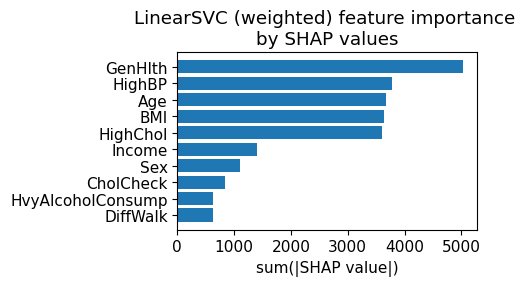

In [164]:
shap_summary = np.sum(np.abs(shap_values[:,:,0]),axis=0)+np.sum(np.abs(shap_values[:,:,1]),axis=0)+np.sum(np.abs(shap_values[:,:,2]),axis=0) 
indcs = np.argsort(shap_summary)
shap_summary[indcs]

plt.figure(figsize=(5,3))
plt.barh(feature_names[indcs[-10:]],shap_summary[indcs[-10:]])
plt.xlabel('sum(|SHAP value|)')
plt.title(f'LinearSVC (weighted) feature importance \nby SHAP values')
plt.tight_layout()
plt.savefig(f"../figures/linsvc_shap.jpg", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

- local feature importances for one observation

In [163]:
index = 8 # the index of the point to explain
for class_num in [0,1,2]:
    display(shap.force_plot(explainer.expected_value[class_num], shap_values[index,:,class_num], features = X_test_scaled[index,:],
                            feature_names = feature_names))
